
2. LOAD DATASET
     Dataset                File    Rows  Columns
       train           train.csv 2565628        6
        test            test.csv   28512        5
      stores          stores.csv      54        5
         oil             oil.csv    1218        2
    holidays holidays_events.csv     350        6
transactions    transactions.csv   83488        3

3. DATASET OVERVIEW

--- TRAIN  |  shape = (2565628, 6) ---
Columns: id (int64), date (object), store_nbr (int64), family (object), sales (float64), onpromotion (float64)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0.00
1,1,2013-01-01,1,BABY CARE,0.00,0.00
2,2,2013-01-01,1,BEAUTY,0.00,0.00



--- TEST  |  shape = (28512, 5) ---
Columns: id (int64), date (object), store_nbr (int64), family (object), onpromotion (int64)


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2



--- STORES  |  shape = (54, 5) ---
Columns: store_nbr (int64), city (object), state (object), store_type (object), cluster (int64)


...


4. DATA QUALITY CHECK


,Dataset,Rows,Columns,Missing cells,Duplicate rows,Invalid dates
0,train,2565628,6,2,0,0
1,test,28512,5,0,0,0
2,stores,54,5,0,0,0
3,oil,1218,2,43,0,0
4,holidays,350,6,0,0,0
5,transactions,83488,3,0,0,0


Columns with missing values: {'train': {'sales': 1, 'onpromotion': 1}, 'oil': {'oil_price': 43}}

Columns only in train: ['sales'] | only in test: []
Train dates: 2013-01-01 to 2016-12-13 | Test dates: 2017-08-16 to 2017-08-31 (no overlap - good)

Sales column summary (row level):
count   2,565,627.00
mean          335.75
std         1,046.91
min             0.00
50%             9.00
99%         5,191.00
99.9%      11,583.51
max       124,717.00
Rows with zero sales: 34.0%  (normal for product families that did not sell that day)

Data Quality Check
------------------
Missing values found : Yes (45 cells)
Duplicate rows       : 0
Invalid dates        : 0
Invalid values       : 0
Result: Issues found. Only these will be corrected in Section 5.

5. DATA CLEANING
• train: removed 1 rows with missing/non-numeric sales
• oil: filled 529 missing daily prices using the last known price
• 6,602 store-days before a store's first sale (store not yet open) removed
• 549 store-days with zero total

,date,store_nbr,sales,onpromotion,city,state,store_type,cluster,store_type_enc,city_enc,state_enc,oil_price,year,month,day,dayofweek,weekofyear,quarter,is_weekend,is_month_start,is_month_end,is_national_holiday,is_regional_holiday,is_local_holiday,is_holiday,is_event,sales_lag_16,sales_avg28_lag_16
0,2013-01-01,25,"2,511.62",0.00,Salinas,Santa Elena,D,1,3,20,13,93.14,2013,1,1,1,1,1,0,1,0,1,0,0,1,0,NaN,NaN
1,2013-01-02,1,"7,417.15",0.00,Quito,Pichincha,D,13,3,18,12,93.14,2013,1,2,2,1,1,0,0,0,0,0,0,0,0,NaN,NaN
2,2013-01-02,2,"10,266.72",0.00,Quito,Pichincha,D,13,3,18,12,93.14,2013,1,2,2,1,1,0,0,0,0,0,0,0,0,NaN,NaN
3,2013-01-02,3,"24,060.35",0.00,Quito,Pichincha,D,8,3,18,12,93.14,2013,1,2,2,1,1,0,0,0,0,0,0,0,0,NaN,NaN
4,2013-01-02,4,"10,200.08",0.00,Quito,Pichincha,D,9,3,18,12,93.14,2013,1,2,2,1,1,0,0,0,0,0,0,0,0,NaN,NaN



7. EXPLORATORY DATA ANALYSIS


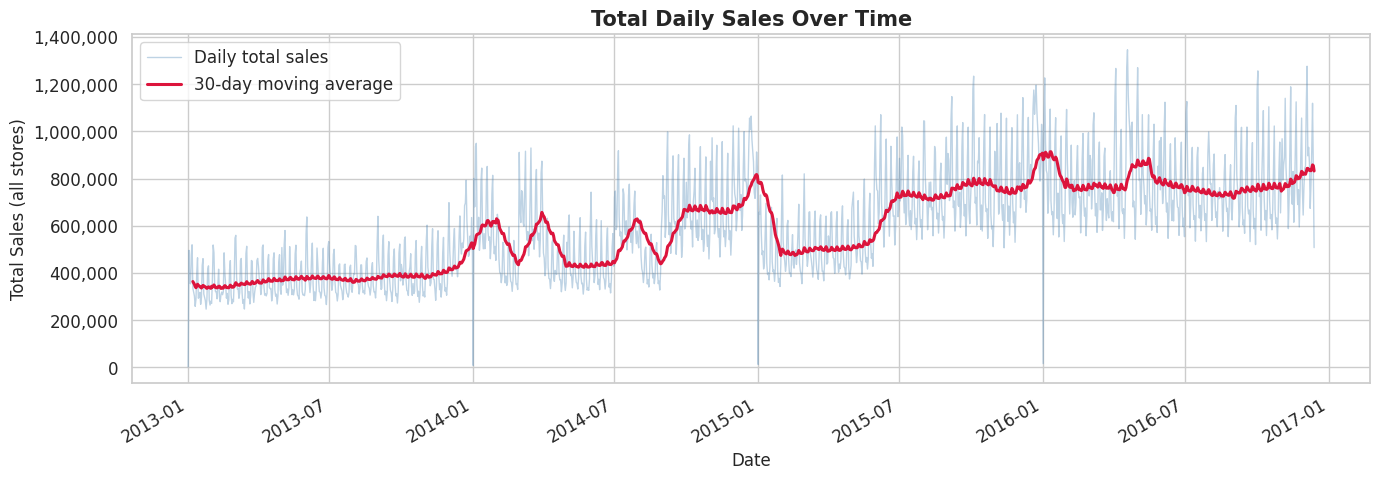

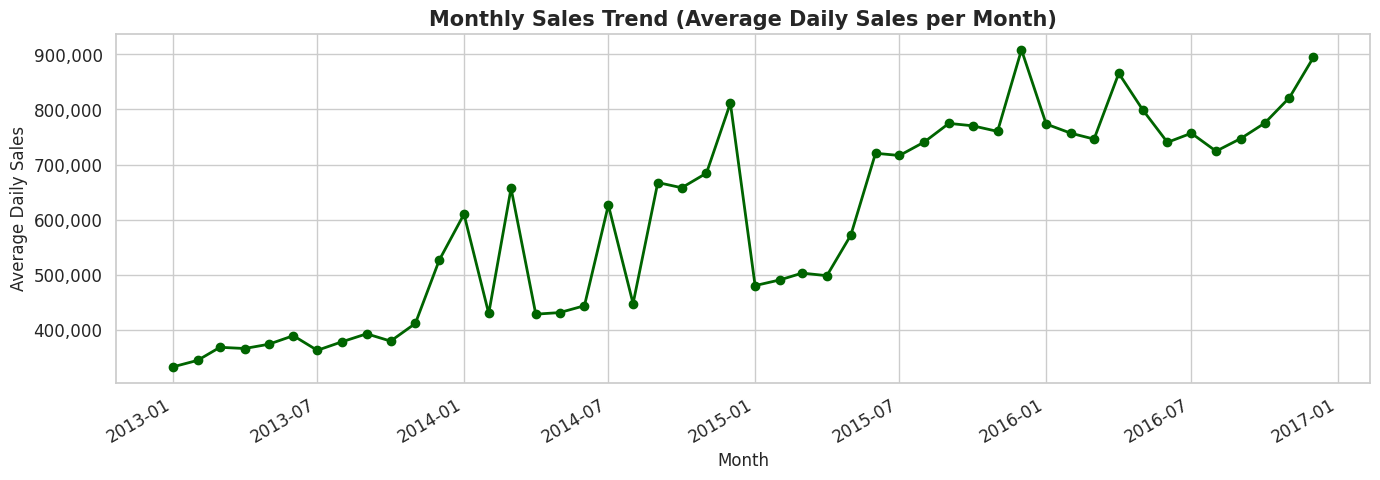

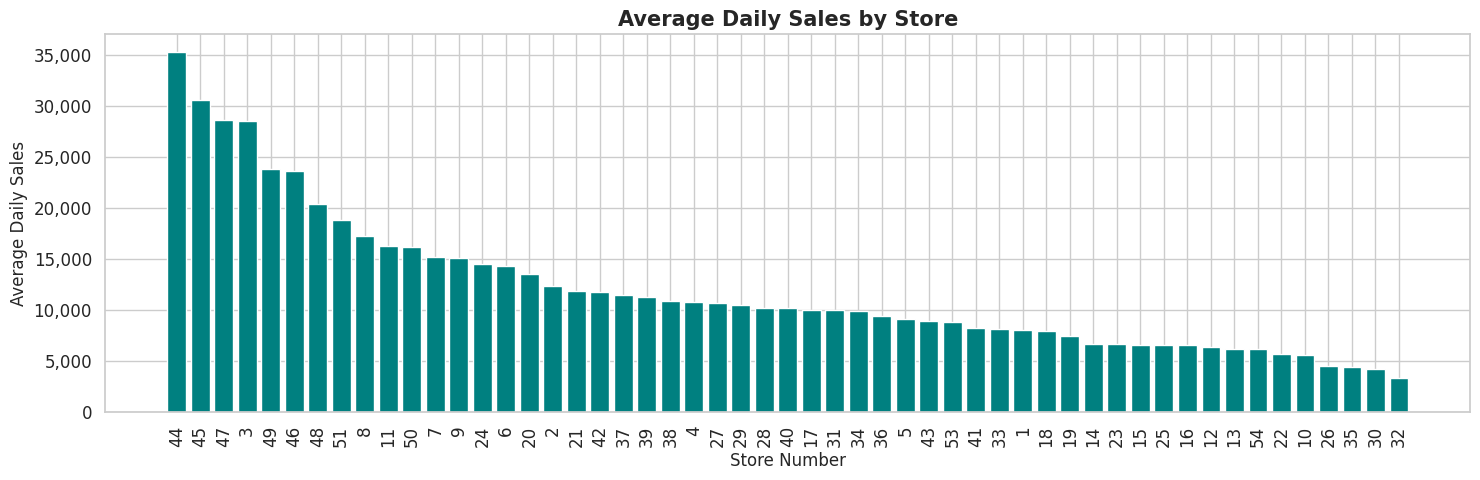

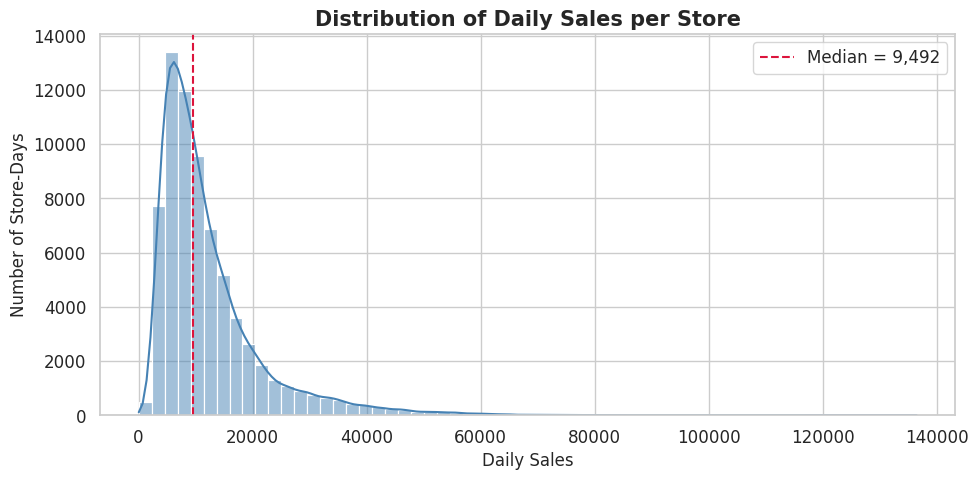

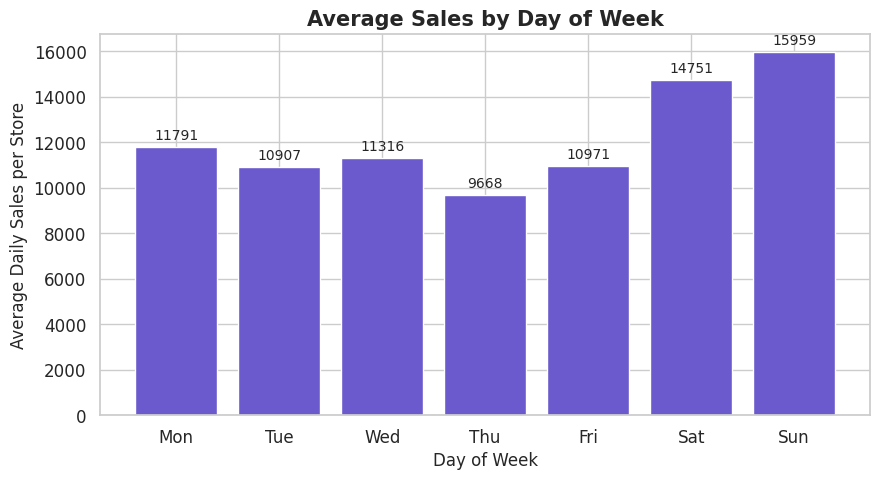

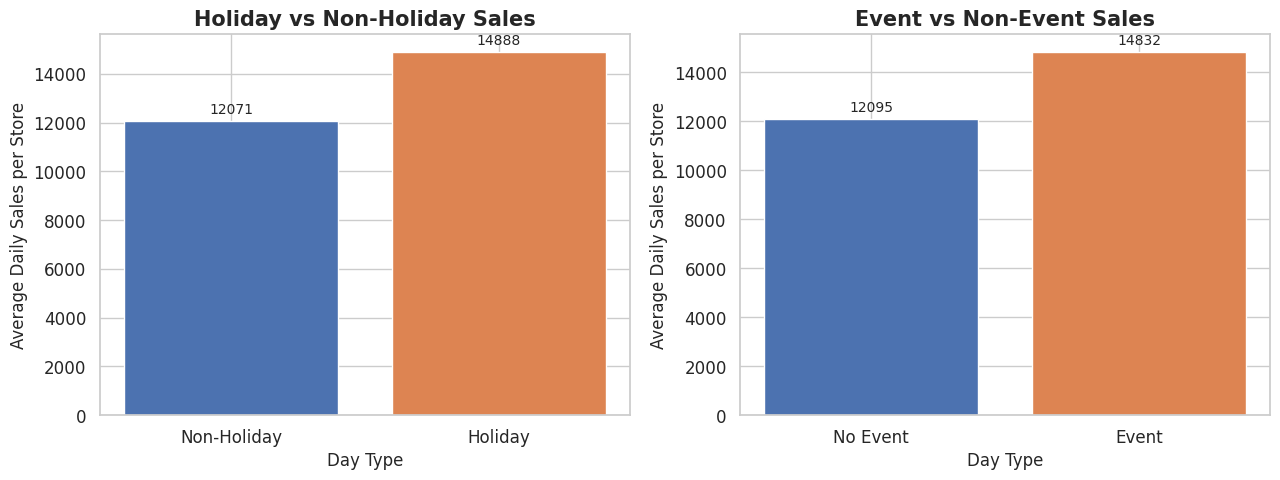

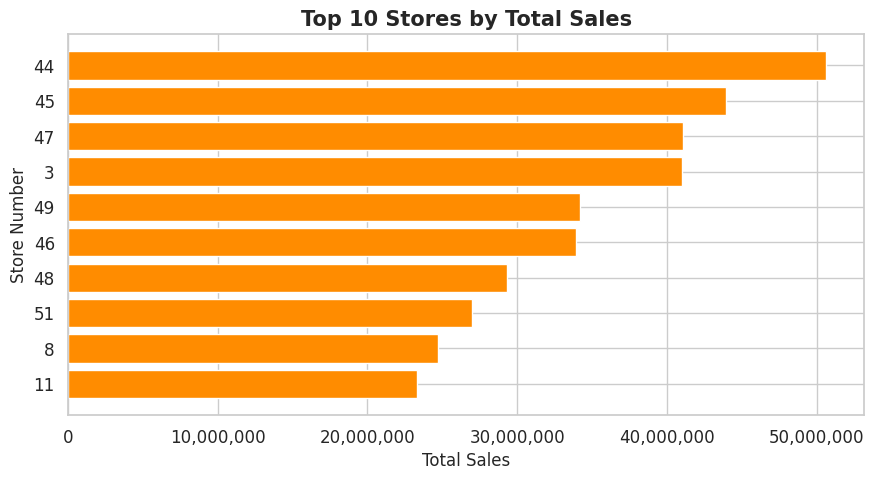

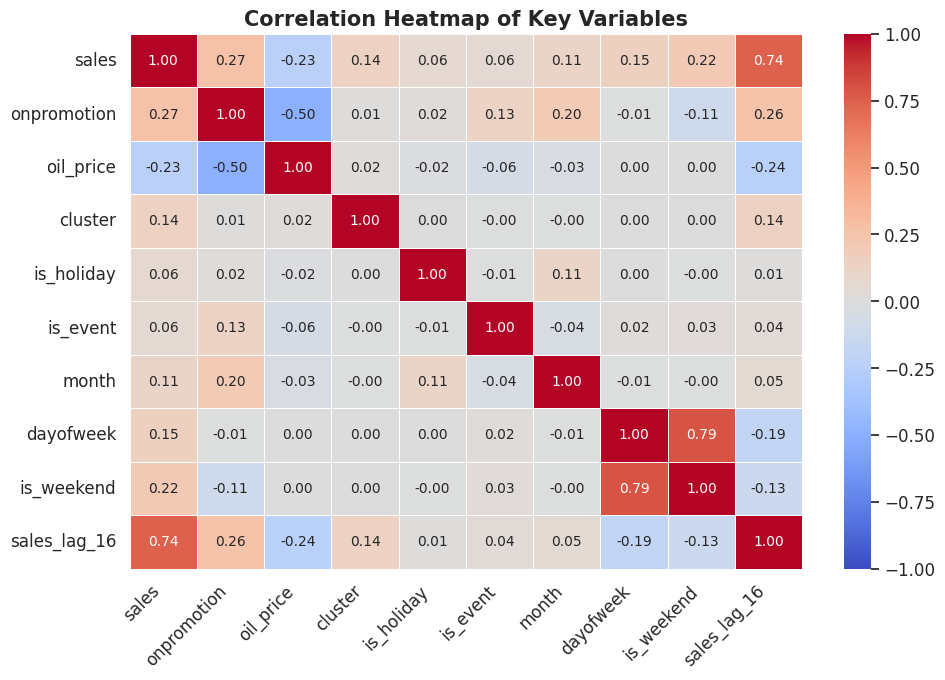


8. TRAIN-TEST SPLIT
Training period : 2013-01-23 to 2016-09-14  (64,414 rows)
Testing period  : 2016-09-15 to 2016-12-13  (4,633 rows)
Features used   : 23

9. MODEL BUILDING
Random Forest model trained successfully.

10. MODEL EVALUATION


,MAE,MSE,RMSE,R² Score
Model,,,,
Baseline (sales 16 days earlier),"4,994.74","68,766,047.99","8,292.53",0.46
Random Forest Regressor,"1,914.40","10,303,865.91","3,209.96",0.92


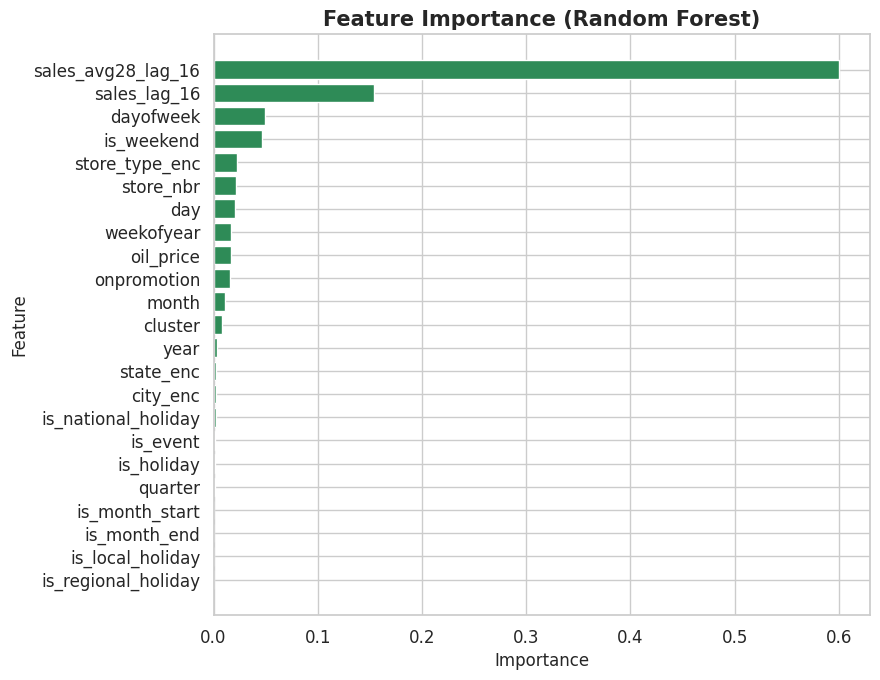


11. ACTUAL vs PREDICTED SALES


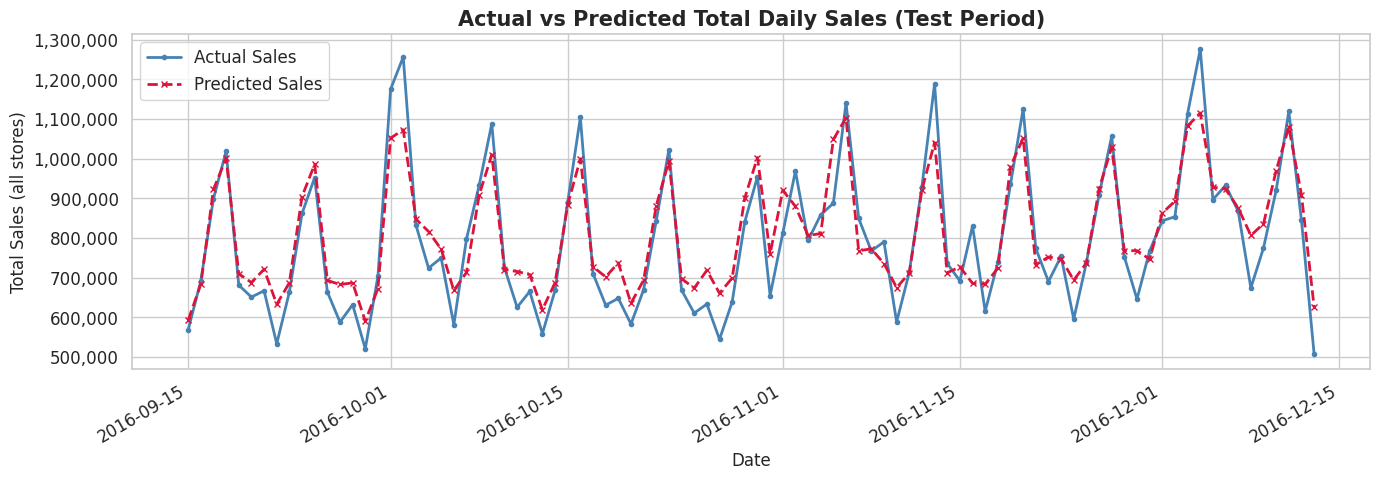

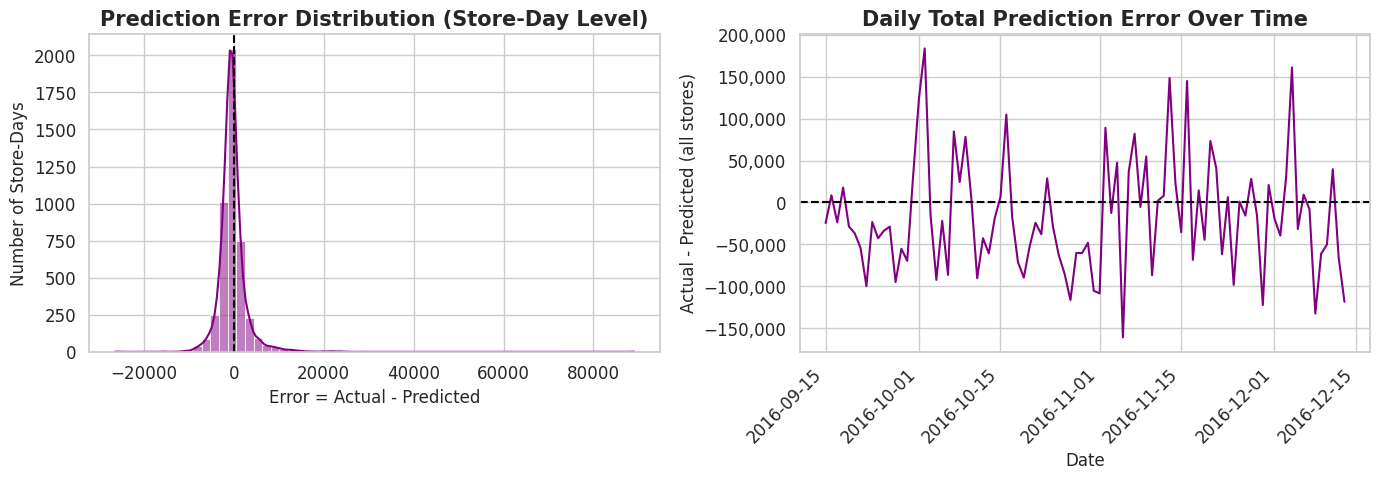

Correlation between actual and predicted daily totals: 0.941
Average error of daily totals (WAPE): 7.01%

12. FUTURE SALES FORECAST


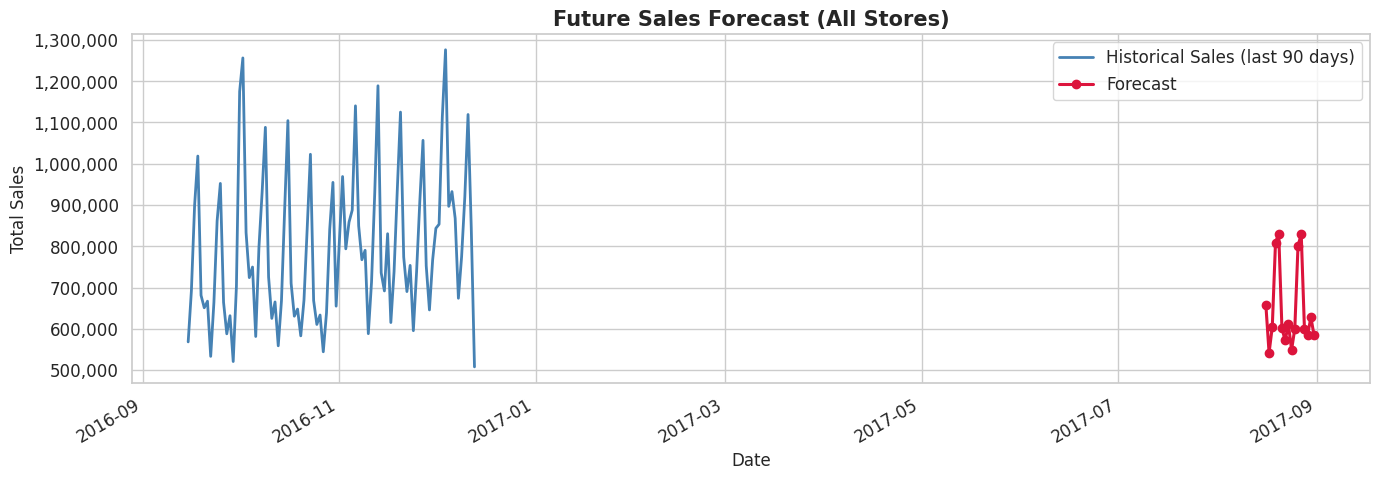

Forecast period: 2017-08-16 to 2017-08-31 (16 days, 54 stores)

13. FINAL RESULTS
Model evaluation metrics (test period):


,MAE,MSE,RMSE,R² Score
Model,,,,
Baseline (sales 16 days earlier),"4,994.74","68,766,047.99","8,292.53",0.46
Random Forest Regressor,"1,914.40","10,303,865.91","3,209.96",0.92



Forecasted total sales per day (all stores):


,Date,Day,Predicted Sales
0,2017-08-16,Wednesday,"658,293.68"
1,2017-08-17,Thursday,"541,957.44"
2,2017-08-18,Friday,"604,966.23"
3,2017-08-19,Saturday,"808,809.16"
4,2017-08-20,Sunday,"830,728.15"
5,2017-08-21,Monday,"601,565.55"
6,2017-08-22,Tuesday,"571,861.08"
7,2017-08-23,Wednesday,"610,938.98"
8,2017-08-24,Thursday,"549,271.80"
9,2017-08-25,Friday,"600,236.11"



Forecasted sales per store (first 15 rows):


,Date,Store,Predicted Sales
0,2017-08-16,1,"8,528.36"
1,2017-08-16,2,"13,424.00"
2,2017-08-16,3,"30,717.77"
3,2017-08-16,4,"12,753.93"
4,2017-08-16,5,"9,718.66"
5,2017-08-16,6,"14,325.46"
6,2017-08-16,7,"14,801.94"
7,2017-08-16,8,"18,171.66"
8,2017-08-16,9,"13,500.62"
9,2017-08-16,10,"6,092.64"


Full forecast saved as: future_sales_forecast.csv

            FINAL PROJECT SUMMARY
Records used (store-days)  : 70,596   (from 2,565,628 raw product-level rows)
Number of stores           : 53
Date range                 : 2013-01-01 to 2016-12-13
Model used                 : Random Forest Regressor (200 trees, max depth 20)
Top features               : sales_avg28_lag_16, sales_lag_16, dayofweek, is_weekend, store_type_enc
MAE                        : 1,914.40
RMSE                       : 3,209.96
R² Score                   : 0.9198
Captured overall trend?    : Yes (correlation 0.94, daily-total error 7.0%)

14. CONCLUSION
• The Random Forest model outperformed the simple baseline (RMSE 3,209.96 vs 8,292.53).
• Sales are highest on Suns and lowest on Thus.
• Store 44 is the top-performing store by total sales.
• Holiday days average +23.3% sales versus normal days.
• The model successfully followed the real sales trend in the 90-day test period.
• Possible improvements: add more year

In [ ]:
# ============================================================
#        STORE SALES FORECASTING USING HISTORICAL RETAIL DATA
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import os, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"axes.titlesize": 15, "axes.titleweight": "bold", "axes.labelsize": 12})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

RANDOM_STATE = 42
TEST_DAYS = 90                                   # last 90 days are kept aside for testing
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

def section(title):
    print("\n" + "=" * 70 + f"\n{title}\n" + "=" * 70)

def safe_divide(a, b):
    return a / b if b not in (0, None) and not pd.isna(b) else np.nan


# ============================================================
# 2. LOAD DATASET  (files are detected automatically)
# ============================================================
section("2. LOAD DATASET")

SEARCH_ROOT = "/content" if os.path.exists("/content") else os.getcwd()
EXTRACT_DIR = os.path.join(SEARCH_ROOT, "store_sales_data")

def list_csvs(root, skip_drive=True):
    """Walk through folders and return every CSV file path."""
    found = []
    for folder, dirs, names in os.walk(root):
        dirs[:] = [d for d in dirs if not d.startswith(".") and d != "sample_data"
                   and not (skip_drive and os.path.join(folder, d) == os.path.join(root, "drive"))]
        found += [os.path.join(folder, n) for n in names if n.lower().endswith(".csv")]
    return found

def has_train(files):
    return any(os.path.basename(f).lower() == "train.csv" for f in files)

csv_files = list_csvs(SEARCH_ROOT)
if not has_train(csv_files):                      # no CSVs yet -> look for a zip and extract it
    zips = [z for z in glob.glob(SEARCH_ROOT + "/**/*.zip", recursive=True) if "/drive/" not in z]
    if not zips:
        try:
            from google.colab import files as colab_files
            print("No dataset found. Please upload the dataset zip file...")
            zips = [os.path.join(SEARCH_ROOT, n) for n in colab_files.upload().keys() if n.endswith(".zip")]
        except ImportError:
            pass
    for z in zips:
        with zipfile.ZipFile(z) as zf:
            zf.extractall(EXTRACT_DIR)
    csv_files = list_csvs(SEARCH_ROOT)
if not has_train(csv_files):                      # last attempt: mounted Google Drive
    csv_files = list_csvs(SEARCH_ROOT, skip_drive=False)

FILE_KEYS = {"train": ["train"], "test": ["test"], "stores": ["stores", "store"],
             "oil": ["oil"], "holidays": ["holidays_events", "holiday"],
             "transactions": ["transactions", "transaction"]}

def locate(keys):
    names = {f: os.path.basename(f).lower().replace(".csv", "")
             for f in csv_files if "sample" not in os.path.basename(f).lower()}
    for k in keys:                                # exact name first
        for f, n in names.items():
            if n == k:
                return f
    for k in keys:                                # then partial name
        for f, n in names.items():
            if k in n:
                return f
    return None

paths = {k: locate(v) for k, v in FILE_KEYS.items()}
if paths["train"] is None or paths["stores"] is None:
    raise FileNotFoundError("train.csv and stores.csv are required. Please upload the dataset and re-run.")

def read_csv_safe(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

# Map possible column names to standard names (avoids KeyError if names differ)
ALIASES = {
    "train": {"date": ["date"], "store_nbr": ["store_nbr", "store", "store_id"],
              "sales": ["sales", "unit_sales"], "onpromotion": ["onpromotion", "promotion", "promo"]},
    "stores": {"store_nbr": ["store_nbr", "store", "store_id"], "city": ["city"], "state": ["state"],
               "store_type": ["type", "store_type"], "cluster": ["cluster"]},
    "oil": {"date": ["date"], "oil_price": ["dcoilwtico", "oil_price", "price"]},
    "holidays": {"date": ["date"], "holiday_type": ["type", "holiday_type"], "locale": ["locale"],
                 "locale_name": ["locale_name"], "transferred": ["transferred"]},
    "transactions": {"date": ["date"], "store_nbr": ["store_nbr", "store", "store_id"],
                     "transactions": ["transactions"]},
}
ALIASES["test"] = ALIASES["train"]

def standardise(name, df):
    lower = {c.lower().strip(): c for c in df.columns}
    rename = {}
    for std, candidates in ALIASES[name].items():
        for cand in candidates:
            if cand in lower:
                if std not in df.columns or lower[cand] == std:
                    rename[lower[cand]] = std
                break
    return df.rename(columns=rename)

raw = {k: standardise(k, read_csv_safe(p)) for k, p in paths.items() if p}

for need, cols in {"train": ["date", "store_nbr", "sales"], "stores": ["store_nbr"]}.items():
    missing = [c for c in cols if c not in raw[need].columns]
    if missing:
        raise ValueError(f"'{need}' file is missing required column(s): {missing}")

print(pd.DataFrame({"Dataset": list(raw.keys()),
                    "File": [os.path.basename(paths[k]) for k in raw],
                    "Rows": [len(v) for v in raw.values()],
                    "Columns": [v.shape[1] for v in raw.values()]}).to_string(index=False))
# Output: table listing every dataset file found, with its number of rows and columns


# ============================================================
# 3. DATASET OVERVIEW
# ============================================================
section("3. DATASET OVERVIEW")
for name, df in raw.items():
    print(f"\n--- {name.upper()}  |  shape = {df.shape} ---")
    print("Columns:", ", ".join(f"{c} ({t})" for c, t in df.dtypes.astype(str).items()))
    display(df.head(3))
# Output: for each file -> shape, column names with data types, and the first 3 rows


# ============================================================
# 4. DATA QUALITY CHECK  (inspection only - nothing is modified here)
# ============================================================
section("4. DATA QUALITY CHECK")

def count_invalid_dates(df):
    if "date" not in df.columns:
        return 0
    return int(pd.to_datetime(df["date"], errors="coerce").isna().sum() - df["date"].isna().sum())

quality = pd.DataFrame([{
    "Dataset": name, "Rows": len(df), "Columns": df.shape[1],
    "Missing cells": int(df.isna().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Invalid dates": count_invalid_dates(df)} for name, df in raw.items()])
display(quality)

missing_detail = {n: d.isna().sum()[d.isna().sum() > 0].to_dict() for n, d in raw.items() if d.isna().any().any()}
print("Columns with missing values:", missing_detail if missing_detail else "None")

# --- Impossible / inconsistent values ---
issues = {}
tr = raw["train"]
sales_num = pd.to_numeric(tr["sales"], errors="coerce")
issues["Non-numeric sales values"] = int(sales_num.isna().sum() - tr["sales"].isna().sum())
issues["Negative sales values"] = int((sales_num < 0).sum())
if "onpromotion" in tr.columns:
    issues["Negative promotion counts"] = int((pd.to_numeric(tr["onpromotion"], errors="coerce") < 0).sum())
if "oil" in raw and "oil_price" in raw["oil"].columns:
    issues["Zero/negative oil prices"] = int((pd.to_numeric(raw["oil"]["oil_price"], errors="coerce") <= 0).sum())
st = raw["stores"]
issues["Duplicate store IDs in stores file"] = int(st["store_nbr"].duplicated().sum())
label_problems = 0
for col in ["city", "state", "store_type"]:
    if col in st.columns:
        s = st[col].dropna().astype(str)
        label_problems += s.nunique() - s.str.strip().str.lower().nunique()
issues["Inconsistent category labels (case/spaces)"] = int(label_problems)

# --- Train / test compatibility ---
if "test" in raw:
    te = raw["test"]
    only_in_test = sorted(set(te.columns) - set(tr.columns))
    only_in_train = sorted(set(tr.columns) - set(te.columns))
    unseen_stores = sorted(set(te["store_nbr"]) - set(tr["store_nbr"])) if "store_nbr" in te.columns else []
    issues["Test columns missing in train"] = len(only_in_test)
    issues["Test stores never seen in train"] = len(unseen_stores)
    tr_dates, te_dates = pd.to_datetime(tr["date"], errors="coerce"), pd.to_datetime(te["date"], errors="coerce")
    print(f"\nColumns only in train: {only_in_train} | only in test: {only_in_test}")
    print(f"Train dates: {tr_dates.min().date()} to {tr_dates.max().date()} | "
          f"Test dates: {te_dates.min().date()} to {te_dates.max().date()} "
          f"({'no overlap - good' if te_dates.min() > tr_dates.max() else 'OVERLAP FOUND'})")
    if te_dates.min() <= tr_dates.max():
        issues["Train/test date overlap"] = 1

# --- Target (sales) investigation ---
zero_share = safe_divide(int((sales_num == 0).sum()), len(sales_num)) * 100
print("\nSales column summary (row level):")
print(sales_num.describe(percentiles=[0.5, 0.99, 0.999]).round(2).to_string())
print(f"Rows with zero sales: {zero_share:.1f}%  (normal for product families that did not sell that day)")

# --- Report ---
total_missing, total_dupes = int(quality["Missing cells"].sum()), int(quality["Duplicate rows"].sum())
total_bad_dates, total_invalid = int(quality["Invalid dates"].sum()), int(sum(issues.values()))
print("\nData Quality Check\n------------------")
print(f"Missing values found : {'Yes' if total_missing else 'No'} ({total_missing:,} cells)")
print(f"Duplicate rows       : {total_dupes:,}")
print(f"Invalid dates        : {total_bad_dates:,}")
print(f"Invalid values       : {total_invalid:,}")
for k, v in issues.items():
    if v:
        print(f"   - {k}: {v:,}")
if total_missing + total_dupes + total_bad_dates + total_invalid == 0:
    print("Result: Dataset is already clean. No unnecessary data modification will be performed.")
else:
    print("Result: Issues found. Only these will be corrected in Section 5.")
# Output: quality table, missing-value columns, compatibility checks, sales summary and a data quality report


# ============================================================
# 5. DATA CLEANING  (corrections only where something is actually wrong)
# ============================================================
section("5. DATA CLEANING")
tables = {k: v.copy() for k, v in raw.items()}
n_raw_train_rows = len(raw["train"])
actions = []

def log(msg):
    actions.append(msg)
    print("•", msg)

# 5.1 Convert dates and remove rows with invalid dates
for name in ["train", "test", "oil", "holidays", "transactions"]:
    if name in tables:
        df = tables[name]
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        bad = int(df["date"].isna().sum())
        if bad:
            tables[name] = df.dropna(subset=["date"]).reset_index(drop=True)
            log(f"{name}: removed {bad} rows with invalid dates")

# 5.2 Remove exact duplicate rows
for name, df in list(tables.items()):
    n = int(df.duplicated().sum())
    if n:
        tables[name] = df.drop_duplicates().reset_index(drop=True)
        log(f"{name}: removed {n:,} duplicate rows")

# 5.3 Sales and promotion values
train = tables["train"]
train["sales"] = pd.to_numeric(train["sales"], errors="coerce")
n_nan_sales = int(train["sales"].isna().sum())
if n_nan_sales:
    train = train.dropna(subset=["sales"])
    log(f"train: removed {n_nan_sales:,} rows with missing/non-numeric sales")
n_neg = int((train["sales"] < 0).sum())
if n_neg:
    train["sales"] = train["sales"].clip(lower=0)
    log(f"train: {n_neg:,} negative sales values set to 0")
for name in ["train", "test"]:
    df = train if name == "train" else tables.get("test")
    if df is not None and "onpromotion" in df.columns:
        df["onpromotion"] = pd.to_numeric(df["onpromotion"], errors="coerce")
        n_bad = int(((df["onpromotion"] < 0) | df["onpromotion"].isna()).sum())
        if n_bad:
            df["onpromotion"] = df["onpromotion"].clip(lower=0).fillna(0)
            log(f"{name}: fixed {n_bad:,} invalid/missing promotion counts (set to 0)")
tables["train"] = train.reset_index(drop=True)

# 5.4 Store labels: remove stray spaces only if present
stores = tables["stores"].drop_duplicates("store_nbr").copy()
for col in ["city", "state", "store_type"]:
    if col in stores.columns:
        cleaned = stores[col].astype(str).str.strip()
        changed = int((cleaned != stores[col].astype(str)).sum())
        if changed:
            stores[col] = cleaned
            log(f"stores: stripped extra spaces in {changed} '{col}' labels")

# 5.5 Oil price: complete daily calendar, fill gaps using PAST values only (no future leakage)
oil_daily = None
if "oil" in tables and "oil_price" in tables["oil"].columns:
    last_date = max(tables["train"]["date"].max(), tables["test"]["date"].max() if "test" in tables else pd.Timestamp.min)
    calendar = pd.date_range(tables["train"]["date"].min(), last_date, freq="D")
    oil = tables["oil"].drop_duplicates("date").set_index("date")["oil_price"]
    oil = pd.to_numeric(oil, errors="coerce").mask(lambda s: s <= 0).reindex(calendar)
    n_gaps = int(oil.isna().sum())
    oil = oil.ffill().bfill()                     # forward-fill (past value); back-fill only for the first days
    oil_daily = oil.rename("oil_price").rename_axis("date").reset_index()
    if n_gaps:
        log(f"oil: filled {n_gaps} missing daily prices using the last known price")

# 5.6 Aggregate to Store-Day level (one row per store per date)
agg = {"sales": ("sales", "sum")}
if "onpromotion" in tables["train"].columns:
    agg["onpromotion"] = ("onpromotion", "sum")
daily = tables["train"].groupby(["date", "store_nbr"], as_index=False).agg(**agg)

future_raw = None
if "test" in tables:
    t = tables["test"]
    if "onpromotion" in t.columns:
        future_raw = t.groupby(["date", "store_nbr"], as_index=False).agg(onpromotion=("onpromotion", "sum"))
    else:
        future_raw = t[["date", "store_nbr"]].drop_duplicates().reset_index(drop=True)

# 5.7 Zero-sales store-days: store not yet opened or closed (no trading = no demand signal)
daily = daily.sort_values(["store_nbr", "date"]).reset_index(drop=True)
first_sale = daily[daily["sales"] > 0].groupby("store_nbr")["date"].min().rename("first_sale_date")
daily = daily.merge(first_sale, on="store_nbr", how="left")
before_opening = daily["first_sale_date"].isna() | (daily["date"] < daily["first_sale_date"])
closed_days = (daily["sales"] == 0) & ~before_opening
if before_opening.sum():
    log(f"{int(before_opening.sum()):,} store-days before a store's first sale (store not yet open) removed")
if closed_days.sum():
    log(f"{int(closed_days.sum()):,} store-days with zero total sales (store closed) removed")
daily = daily[~before_opening & ~closed_days].drop(columns="first_sale_date")

# 5.8 Outlier investigation (investigate only - genuine high-sales days are KEPT)
grp = daily.groupby("store_nbr")["sales"]
q1, q3 = grp.transform(lambda s: s.quantile(0.25)), grp.transform(lambda s: s.quantile(0.75))
extreme_mask = daily["sales"] > (q3 + 3 * (q3 - q1))
print(f"\nOutlier check: {int(extreme_mask.sum()):,} extreme-high store-days "
      f"({safe_divide(extreme_mask.sum(), len(daily)) * 100:.2f}%) found using the 3×IQR rule per store.")
if extreme_mask.any():
    print("Dates with most extreme values:")
    print(daily[extreme_mask].groupby("date").size().sort_values(ascending=False).head(5).to_string())
    print("Decision: kept - these look like genuine high-sales days (holidays/promotions), not data errors.")

daily = daily.sort_values(["date", "store_nbr"]).reset_index(drop=True)
assert np.isfinite(daily["sales"]).all(), "Non-finite sales values remain"
if not actions:
    print("\nNo data errors were found - no corrections were needed.")
print(f"\nCleaned store-day data: {daily.shape} | {daily['date'].min().date()} to {daily['date'].max().date()}")
# Output: list of cleaning actions with counts, outlier summary, and the cleaned store-day dataset shape


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================
section("6. FEATURE ENGINEERING")

# --- 6.1 Holiday and event lookup tables (transferred holidays were NOT celebrated, so they are ignored) ---
hol = {"national": set(), "regional": set(), "local": set(), "event": set()}
if "holidays" in tables and {"date", "holiday_type", "locale"}.issubset(tables["holidays"].columns):
    h = tables["holidays"].copy()
    if "transferred" in h.columns:
        h = h[~h["transferred"].astype(str).str.lower().eq("true")]
    h_type, h_locale = h["holiday_type"].astype(str).str.lower(), h["locale"].astype(str).str.lower()
    is_hol = h_type.isin(["holiday", "transfer", "additional", "bridge"])   # 'Work Day' is NOT a holiday
    hol["event"] = set(h.loc[h_type.eq("event"), "date"])
    hol["national"] = set(h.loc[is_hol & h_locale.eq("national"), "date"])
    if "locale_name" in h.columns:
        hol["regional"] = set(zip(h.loc[is_hol & h_locale.eq("regional"), "date"],
                                  h.loc[is_hol & h_locale.eq("regional"), "locale_name"]))
        hol["local"] = set(zip(h.loc[is_hol & h_locale.eq("local"), "date"],
                               h.loc[is_hol & h_locale.eq("local"), "locale_name"]))

# --- 6.2 Store information + label encoding (fitted on the stores table only) ---
store_cols = [c for c in ["store_nbr", "city", "state", "store_type", "cluster"] if c in stores.columns]
store_info = stores[store_cols].copy()
if "cluster" in store_info.columns:
    store_info["cluster"] = pd.to_numeric(store_info["cluster"], errors="coerce")
encoders = {}
for col in ["store_type", "city", "state"]:
    if col in store_info.columns:
        store_info[col] = store_info[col].fillna("Unknown").astype(str)
        encoders[col] = LabelEncoder().fit(list(store_info[col].unique()) + ["Unknown"])

# --- 6.3 Lag settings: predictions use only sales that are at least HORIZON days old ---
HORIZON = int(future_raw["date"].nunique()) if future_raw is not None else 16
HORIZON = max(1, min(HORIZON, 60))
LAG_COL, ROLL_COL = f"sales_lag_{HORIZON}", f"sales_avg28_lag_{HORIZON}"

def make_features(df):
    out = df.merge(store_info, on="store_nbr", how="left")
    for col, enc in encoders.items():
        out[col] = out[col].fillna("Unknown").astype(str)
        out[col + "_enc"] = enc.transform(out[col])                # store type / city / state as numbers
    if oil_daily is not None:
        out = out.merge(oil_daily, on="date", how="left")          # oil price (economic factor)
        out["oil_price"] = out["oil_price"].fillna(oil_daily["oil_price"].median())

    # Time-based features
    out["year"] = out["date"].dt.year                              # long-term growth
    out["month"] = out["date"].dt.month                            # yearly seasonality
    out["day"] = out["date"].dt.day                                # day of month (pay-cycle effects)
    out["dayofweek"] = out["date"].dt.dayofweek                    # 0 = Monday ... 6 = Sunday
    out["weekofyear"] = out["date"].dt.isocalendar().week.astype(int)
    out["quarter"] = out["date"].dt.quarter                        # business quarter
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)        # weekend shopping behaviour
    out["is_month_start"] = out["date"].dt.is_month_start.astype(int)
    out["is_month_end"] = out["date"].dt.is_month_end.astype(int)

    # Holiday and event features
    out["is_national_holiday"] = out["date"].isin(hol["national"]).astype(int)
    if "state" in out.columns:                                     # regional holiday in the store's state
        out["is_regional_holiday"] = [int((d, s) in hol["regional"]) for d, s in zip(out["date"], out["state"])]
    else:
        out["is_regional_holiday"] = 0
    if "city" in out.columns:                                      # local holiday in the store's city
        out["is_local_holiday"] = [int((d, c) in hol["local"]) for d, c in zip(out["date"], out["city"])]
    else:
        out["is_local_holiday"] = 0
    out["is_holiday"] = out[["is_national_holiday", "is_regional_holiday", "is_local_holiday"]].max(axis=1)
    out["is_event"] = out["date"].isin(hol["event"]).astype(int)   # special events (e.g. Mother's Day)
    return out

def add_lag_features(history, future_df):
    """Past-sales features. Lag = HORIZON days, so they are available even for the forecast period."""
    parts = [history[["date", "store_nbr", "sales"]]]
    if future_df is not None:
        parts.append(future_df[["date", "store_nbr"]])
    full = pd.concat(parts, ignore_index=True).drop_duplicates(["date", "store_nbr"], keep="first")
    wide = full.pivot(index="date", columns="store_nbr", values="sales")
    wide = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq="D"))
    wide.index.name = "date"
    lagged = wide.shift(HORIZON)                                   # sales HORIZON days earlier
    rolled = lagged.rolling(28, min_periods=7).mean()              # average of the 28 days before that

    def to_long(w, name):
        out = w.reset_index().melt(id_vars="date", var_name="store_nbr", value_name=name)
        out["store_nbr"] = out["store_nbr"].astype(history["store_nbr"].dtype)
        return out

    lag_long = to_long(lagged, LAG_COL).merge(to_long(rolled, ROLL_COL), on=["date", "store_nbr"])
    history = history.merge(lag_long, on=["date", "store_nbr"], how="left")
    if future_df is not None:
        future_df = future_df.merge(lag_long, on=["date", "store_nbr"], how="left")
    return history, future_df

data = make_features(daily)
future = make_features(future_raw) if future_raw is not None else None
data, future = add_lag_features(data, future)
data = data.sort_values(["date", "store_nbr"]).reset_index(drop=True)

print(f"Feature-engineered data: {data.shape}")
display(data.head())
# Output: DataFrame with time features, holiday/event flags, store features, oil price and lag features


# ============================================================
# 7. EXPLORATORY DATA ANALYSIS
# ============================================================
section("7. EXPLORATORY DATA ANALYSIS")
total_daily = data.groupby("date")["sales"].sum()

# --- 7.1 Overall sales trend ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(total_daily.index, total_daily.values, color="steelblue", alpha=0.35, lw=1, label="Daily total sales")
ax.plot(total_daily.index, total_daily.rolling(30, min_periods=7).mean(), color="crimson", lw=2.2,
        label="30-day moving average")
ax.set(title="Total Daily Sales Over Time", xlabel="Date", ylabel="Total Sales (all stores)")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()
# Output: line graph showing the long-term sales trend and yearly seasonality

# --- 7.2 Monthly sales trend ---
monthly = total_daily.resample("MS").mean()                         # average DAILY sales per month (fair for partial months)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly.values, marker="o", color="darkgreen", lw=2)
ax.set(title="Monthly Sales Trend (Average Daily Sales per Month)", xlabel="Month", ylabel="Average Daily Sales")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()
# Output: line graph of average daily sales for each month

# --- 7.3 Sales by store (average daily sales, fair for stores that opened later) ---
store_avg = data.groupby("store_nbr")["sales"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(store_avg.index.astype(str), store_avg.values, color="teal")
ax.set(title="Average Daily Sales by Store", xlabel="Store Number", ylabel="Average Daily Sales")
ax.tick_params(axis="x", rotation=90); ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()
# Output: sorted bar chart comparing all stores

# --- 7.4 Sales distribution ---
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data["sales"], bins=60, kde=True, color="steelblue", ax=ax)
ax.axvline(data["sales"].median(), color="crimson", ls="--", label=f"Median = {data['sales'].median():,.0f}")
ax.set(title="Distribution of Daily Sales per Store", xlabel="Daily Sales", ylabel="Number of Store-Days")
ax.legend(); plt.tight_layout(); plt.show()
# Output: right-skewed histogram - a few very high-sales days, most days are moderate

# --- 7.5 Sales by day of week ---
dow_mean = data.groupby("dayofweek")["sales"].mean()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([DAY_NAMES[i] for i in dow_mean.index], dow_mean.values, color="slateblue")
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)
ax.set(title="Average Sales by Day of Week", xlabel="Day of Week", ylabel="Average Daily Sales per Store")
plt.tight_layout(); plt.show()
# Output: bar chart showing which weekdays sell the most

# --- 7.6 & 7.7 Holiday vs non-holiday and Event vs non-event ---
panels = []
if data["is_holiday"].sum() > 0:
    panels.append(("is_holiday", "Holiday vs Non-Holiday Sales", ["Non-Holiday", "Holiday"]))
if data["is_event"].sum() > 0:
    panels.append(("is_event", "Event vs Non-Event Sales", ["No Event", "Event"]))
holiday_note = ""
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(6.5 * len(panels), 5), squeeze=False)
    for ax, (col, title, labels) in zip(axes[0], panels):
        means = data.groupby(col)["sales"].mean().reindex([0, 1])
        bars = ax.bar(labels, means.values, color=["#4C72B0", "#DD8452"])
        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)
        ax.set(title=title, xlabel="Day Type", ylabel="Average Daily Sales per Store")
        if col == "is_holiday" and means.notna().all():
            holiday_note = f"Holiday days average {safe_divide(means[1], means[0]) * 100 - 100:+.1f}% sales versus normal days."
    plt.tight_layout(); plt.show()
else:
    print("No holiday/event information available - holiday and event charts skipped.")
# Output: bar charts comparing average sales on holidays/events with normal days

# --- 7.8 Top-performing stores ---
top_stores = data.groupby("store_nbr")["sales"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_stores.index.astype(str)[::-1], top_stores.values[::-1], color="darkorange")
ax.set(title="Top 10 Stores by Total Sales", xlabel="Total Sales", ylabel="Store Number")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}")); plt.tight_layout(); plt.show()
# Output: horizontal bar chart of the 10 best-performing stores

# --- 7.9 Correlation heatmap ---
corr_cols = [c for c in ["sales", "onpromotion", "oil_price", "cluster", "is_holiday", "is_event",
                         "month", "dayofweek", "is_weekend", LAG_COL] if c in data.columns]
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 10}, ax=ax)
ax.set_title("Correlation Heatmap of Key Variables"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()
# Output: correlation heatmap (past sales and promotions correlate most with sales)


# ============================================================
# 8. TRAIN-TEST SPLIT  (chronological - no shuffling)
# ============================================================
section("8. TRAIN-TEST SPLIT")

candidate_features = ["store_nbr", "cluster", "store_type_enc", "city_enc", "state_enc", "onpromotion", "oil_price",
                      "is_holiday", "is_national_holiday", "is_regional_holiday", "is_local_holiday", "is_event",
                      "year", "month", "day", "dayofweek", "weekofyear", "quarter", "is_weekend",
                      "is_month_start", "is_month_end", LAG_COL, ROLL_COL]
FEATURES = [c for c in candidate_features if c in data.columns]
TARGET = "sales"

span_days = (data["date"].max() - data["date"].min()).days
if span_days < TEST_DAYS * 3:
    TEST_DAYS = max(14, span_days // 5)
split_date = data["date"].max() - pd.Timedelta(days=TEST_DAYS)

train_df = data[data["date"] <= split_date].dropna(subset=[LAG_COL, ROLL_COL]).copy()
test_df = data[data["date"] > split_date].copy()
store_mean = train_df.groupby("store_nbr")["sales"].mean()            # from TRAINING data only
train_medians = train_df[FEATURES].replace([np.inf, -np.inf], np.nan).median()

def prepare_matrix(df):
    """Remove inf/NaN so the model never fails; fills use training-period statistics only."""
    X = df[FEATURES].replace([np.inf, -np.inf], np.nan)
    for col in (LAG_COL, ROLL_COL):
        if col in X.columns:
            X[col] = X[col].fillna(df["store_nbr"].map(store_mean))
    return X.fillna(train_medians)

X_train, y_train = prepare_matrix(train_df), train_df[TARGET]
X_test, y_test = prepare_matrix(test_df), test_df[TARGET]

print(f"Training period : {train_df['date'].min().date()} to {train_df['date'].max().date()}  ({len(X_train):,} rows)")
print(f"Testing period  : {test_df['date'].min().date()} to {test_df['date'].max().date()}  ({len(X_test):,} rows)")
print(f"Features used   : {len(FEATURES)}")
# Output: training/testing date ranges, number of rows and number of features


# ============================================================
# 9. MODEL BUILDING
# ============================================================
section("9. MODEL BUILDING")
rf_params = dict(n_estimators=200, max_depth=20, min_samples_leaf=3, max_features=0.7,
                 n_jobs=-1, random_state=RANDOM_STATE)
model = RandomForestRegressor(**rf_params)
model.fit(X_train, y_train)
y_pred = np.clip(model.predict(X_test), 0, None)                      # sales cannot be negative
print("Random Forest model trained successfully.")
# Output: confirmation message


# ============================================================
# 10. MODEL EVALUATION
# ============================================================
section("10. MODEL EVALUATION")

def evaluate(y_true, y_hat, label):
    mse = mean_squared_error(y_true, y_hat)
    return {"Model": label, "MAE": mean_absolute_error(y_true, y_hat), "MSE": mse,
            "RMSE": np.sqrt(mse), "R² Score": r2_score(y_true, y_hat)}

baseline_pred = X_test[LAG_COL].values                                # simple benchmark: "same as HORIZON days ago"
results = pd.DataFrame([evaluate(y_test, baseline_pred, f"Baseline (sales {HORIZON} days earlier)"),
                        evaluate(y_test, y_pred, "Random Forest Regressor")])
display(results.round({"MAE": 2, "MSE": 2, "RMSE": 2, "R² Score": 4}).set_index("Model"))

importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance.index, importance.values, color="seagreen")
ax.set(title="Feature Importance (Random Forest)", xlabel="Importance", ylabel="Feature")
plt.tight_layout(); plt.show()
# Output: table with MAE, MSE, RMSE and R² for baseline vs Random Forest, plus a feature importance chart


# ============================================================
# 11. ACTUAL vs PREDICTED SALES
# ============================================================
section("11. ACTUAL vs PREDICTED SALES")
compare = test_df[["date", "store_nbr", "sales"]].assign(predicted=y_pred)
compare["residual"] = compare["sales"] - compare["predicted"]
daily_cmp = compare.groupby("date")[["sales", "predicted", "residual"]].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_cmp.index, daily_cmp["sales"], color="steelblue", lw=2, marker="o", markersize=3, label="Actual Sales")
ax.plot(daily_cmp.index, daily_cmp["predicted"], color="crimson", lw=2, ls="--", marker="x", markersize=4,
        label="Predicted Sales")
ax.set(title="Actual vs Predicted Total Daily Sales (Test Period)", xlabel="Date", ylabel="Total Sales (all stores)")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

# Prediction error (residual) visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(compare["residual"], bins=60, kde=True, color="purple", ax=axes[0])
axes[0].axvline(0, color="black", ls="--")
axes[0].set(title="Prediction Error Distribution (Store-Day Level)", xlabel="Error = Actual - Predicted",
            ylabel="Number of Store-Days")
axes[1].plot(daily_cmp.index, daily_cmp["residual"], color="purple", lw=1.5)
axes[1].axhline(0, color="black", ls="--")
axes[1].set(title="Daily Total Prediction Error Over Time", xlabel="Date", ylabel="Actual - Predicted (all stores)")
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.show()

trend_corr = daily_cmp["sales"].corr(daily_cmp["predicted"])
wape = safe_divide((daily_cmp["sales"] - daily_cmp["predicted"]).abs().sum(), daily_cmp["sales"].sum())
trend_captured = bool(pd.notna(trend_corr) and trend_corr >= 0.90 and pd.notna(wape) and wape <= 0.15)
print(f"Correlation between actual and predicted daily totals: {trend_corr:.3f}")
print(f"Average error of daily totals (WAPE): {wape * 100:.2f}%")
# Output: actual vs predicted line graph, residual charts, trend-correlation and error percentage


# ============================================================
# 12. FUTURE SALES FORECAST
# ============================================================
section("12. FUTURE SALES FORECAST")
forecast, forecast_total = None, None
if future is None:
    print("No test/future file was found, so a future forecast cannot be generated.")
else:
    # Retrain on ALL available history, then predict the dates provided in the test file
    full_df = data.dropna(subset=[LAG_COL, ROLL_COL])
    final_model = RandomForestRegressor(**rf_params)
    final_model.fit(prepare_matrix(full_df), full_df[TARGET])

    future = future.sort_values(["date", "store_nbr"]).reset_index(drop=True)
    future["predicted_sales"] = np.clip(final_model.predict(prepare_matrix(future)), 0, None).round(2)

    forecast = future[["date", "store_nbr", "predicted_sales"]].rename(
        columns={"date": "Date", "store_nbr": "Store", "predicted_sales": "Predicted Sales"})
    forecast_total = forecast.groupby("Date", as_index=False)["Predicted Sales"].sum()

    history = total_daily.tail(90)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(history.index, history.values, color="steelblue", lw=2, label="Historical Sales (last 90 days)")
    ax.plot(forecast_total["Date"], forecast_total["Predicted Sales"], color="crimson", lw=2.2, marker="o",
            label="Forecast")
    ax.set(title="Future Sales Forecast (All Stores)", xlabel="Date", ylabel="Total Sales")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()
    print(f"Forecast period: {forecast['Date'].min().date()} to {forecast['Date'].max().date()} "
          f"({forecast['Date'].nunique()} days, {forecast['Store'].nunique()} stores)")
# Output: line graph with the last 90 days of history followed by the forecast


# ============================================================
# 13. FINAL RESULTS
# ============================================================
section("13. FINAL RESULTS")

print("Model evaluation metrics (test period):")
display(results.round({"MAE": 2, "MSE": 2, "RMSE": 2, "R² Score": 4}).set_index("Model"))

if forecast is not None:
    print("\nForecasted total sales per day (all stores):")
    display(forecast_total.assign(Day=forecast_total["Date"].dt.day_name())
            [["Date", "Day", "Predicted Sales"]].round(2))
    print("\nForecasted sales per store (first 15 rows):")
    display(forecast.head(15))
    forecast.to_csv("future_sales_forecast.csv", index=False)
    print("Full forecast saved as: future_sales_forecast.csv")

rf_row = results.iloc[-1]
print("\n" + "=" * 70 + "\n            FINAL PROJECT SUMMARY\n" + "=" * 70)
print(f"Records used (store-days)  : {len(data):,}   (from {n_raw_train_rows:,} raw product-level rows)")
print(f"Number of stores           : {data['store_nbr'].nunique()}")
print(f"Date range                 : {data['date'].min().date()} to {data['date'].max().date()}")
print(f"Model used                 : Random Forest Regressor ({rf_params['n_estimators']} trees, "
      f"max depth {rf_params['max_depth']})")
print(f"Top features               : {', '.join(importance.sort_values(ascending=False).head(5).index)}")
print(f"MAE                        : {rf_row['MAE']:,.2f}")
print(f"RMSE                       : {rf_row['RMSE']:,.2f}")
print(f"R² Score                   : {rf_row['R² Score']:.4f}")
print(f"Captured overall trend?    : {'Yes' if trend_captured else 'Partially'} "
      f"(correlation {trend_corr:.2f}, daily-total error {wape * 100:.1f}%)")
# Output: metrics table, forecast tables and a concise final project summary


# ============================================================
# 14. CONCLUSION
# ============================================================
section("14. CONCLUSION")
beat_baseline = rf_row["RMSE"] < results.iloc[0]["RMSE"]
print(f"• The Random Forest model {'outperformed' if beat_baseline else 'did not outperform'} the simple baseline "
      f"(RMSE {rf_row['RMSE']:,.2f} vs {results.iloc[0]['RMSE']:,.2f}).")
print(f"• Sales are highest on {DAY_NAMES[int(dow_mean.idxmax())]}s and lowest on {DAY_NAMES[int(dow_mean.idxmin())]}s.")
print(f"• Store {top_stores.index[0]} is the top-performing store by total sales.")
if holiday_note:
    print(f"• {holiday_note}")
print(f"• The model {'successfully followed' if trend_captured else 'only partly followed'} the real sales trend "
      f"in the {TEST_DAYS}-day test period.")
print("• Possible improvements: add more years of seasonality features, try Gradient Boosting, "
      "and forecast at product-family level.")